In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../../data/preprocessed/imputed_data.csv')

feature_cols = [col for col in df.columns if col not in
                ["result_match", "stage", "season" ,"date", "home_team", "away_team"]]

X = df.drop('result_match', axis=1)
y = df[['result_match']]
X = X[feature_cols]


def freedman_diaconis_bins(series):
    """
    Calculate the optimal number of bins using the Freedman-Diaconis rule.
    """
    data = series.dropna()

    q25, q75 = np.percentile(data, [25, 75])
    iqr = q75 - q25

    bin_width = 2 * iqr / np.cbrt(len(data))

    if bin_width == 0:
        return 10

    data_range = data.max() - data.min()
    n_bins = int(np.ceil(data_range / bin_width))
    return n_bins

Optimal bins for rolling_avg_goals_home: 47
Optimal bins for rolling_avg_shoton_home: 47


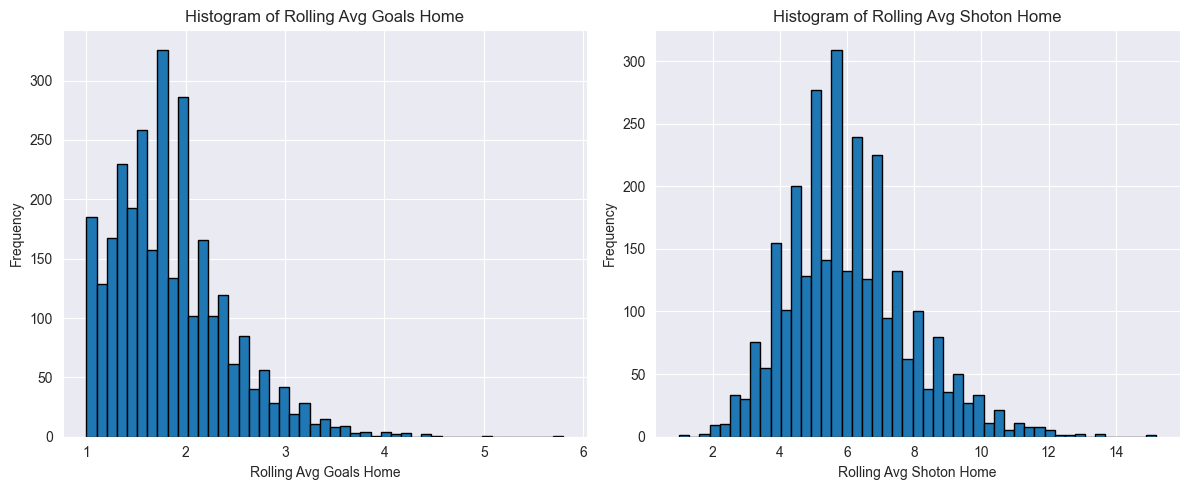

In [2]:
n_bins_goals = freedman_diaconis_bins(X['rolling_avg_goals_home'])
n_bins_shoton = freedman_diaconis_bins(X['rolling_avg_shoton_home'])

print(f"Optimal bins for rolling_avg_goals_home: {n_bins_goals}")
print(f"Optimal bins for rolling_avg_shoton_home: {n_bins_shoton}")

X['goals_bin'] = pd.cut(X['rolling_avg_goals_home'], bins=n_bins_goals).cat.codes
X['shoton_bin'] = pd.cut(X['rolling_avg_shoton_home'], bins=n_bins_shoton).cat.codes

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['rolling_avg_goals_home'].dropna(), bins=n_bins_goals, edgecolor='black')
plt.title('Histogram of Rolling Avg Goals Home')
plt.xlabel('Rolling Avg Goals Home')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(df['rolling_avg_shoton_home'].dropna(), bins=n_bins_shoton, edgecolor='black')
plt.title('Histogram of Rolling Avg Shoton Home')
plt.xlabel('Rolling Avg Shoton Home')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [3]:
# Optional: Display the first few rows to verify
X[['rolling_avg_goals_home', 'goals_bin', 'rolling_avg_shoton_home', 'shoton_bin']]

,rolling_avg_goals_home,goals_bin,rolling_avg_shoton_home,shoton_bin
0,1.000000,0,12.0,36
1,2.000000,9,5.0,13
2,1.000000,0,7.0,19
3,3.000000,19,5.0,13
4,1.000000,0,5.0,13
...,...,...,...,...
2973,1.200000,1,5.2,13
2974,2.466667,14,5.0,13
2975,1.900000,8,8.4,24
2976,1.750000,7,3.6,8


In [6]:
X.columns

Index(['match_api_id', 'points_home', 'points_away', 'home_last_team_goal',
       'home_last_team_shoton', 'home_last_team_possession',
       'away_last_team_goal', 'away_last_team_shoton',
       'away_last_team_possession', 'team_strength_home', 'team_strength_away',
       'strength_difference', 'team_aggression_home', 'team_aggression_away',
       'aggression_difference', 'team_acceleration_home',
       'team_acceleration_away', 'acceleration_difference',
       'goal_conversion_rate_home', 'goal_conversion_rate_away',
       'rolling_avg_goals_home', 'rolling_stability_goal_home',
       'rolling_avg_goals_conversion_rate_home',
       'rolling_stability_goals_conversion_rate_home',
       'rolling_avg_shoton_home', 'rolling_stability_shoton_home',
       'rolling_avg_goals_away', 'rolling_stability_goal_away',
       'rolling_avg_goals_conversion_rate_away',
       'rolling_stability_goals_conversion_rate_away',
       'rolling_avg_shoton_away', 'rolling_stability_shoton_away

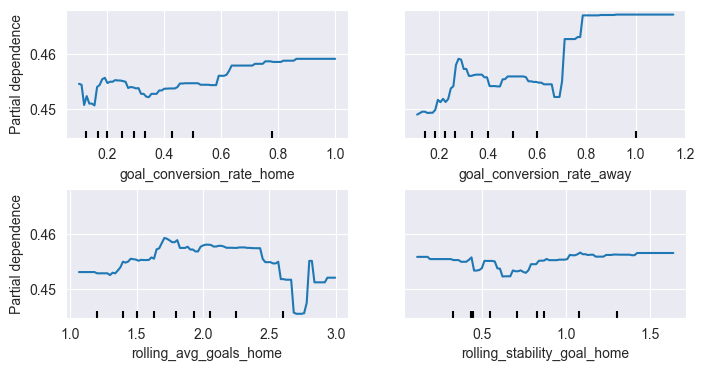

In [12]:
from src.eda.PartialDependencyAnalyzer import PartialDependenceAnalyzer

analyzer = PartialDependenceAnalyzer(
    features=[
        'goal_conversion_rate_home', 'goal_conversion_rate_away',
       'rolling_avg_goals_home', 'rolling_stability_goal_home',
    ],
    model_params={
        'max_depth': 5,
        'n_estimators': 400
    }
)

analyzer.fit_and_visualize(X, y)

In [ ]:
potential_features_for_binning=['home_last_team_possession',
                                'rolling_avg_goals_home', # [-inf - 1.5, 1.5 - 2.5, 2.5 - -inf]
                                'rolling_avg_shoton_home', # [-inf - 5, 5 - 6.4, 6.4 - -inf]
                                'away_last_team_possession',
                                'team_acceleration_home',
                                'acceleration_difference',
                                'goal_conversion_rate_home', # [-inf-0.2, 0,2-0,6, 0,6-inf+]
                                'goal_conversion_rate_away' # [-inf-0.3, 0,3]

                                ]